# Topic 5 — Multiclass Classification: TensorFlow vs sklearn

Dataset: [AeroScan Military Aircraft](https://www.kaggle.com/datasets/ahnuf05/aeroscan-military-aircraft-classification)  
87 aircraft classes. Labels are read from **folder names** (each folder = one class).  
The `.txt` files contain YOLO bounding-box annotations — we ignore them here.

**Pipeline**: load images → flatten → TF deep net vs sklearn MLP, compare accuracy.

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import os
from PIL import Image

import tensorflow as tf
from tensorflow import keras
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

print('TF version:', tf.__version__)

TF version: 2.21.0


## 1. Download dataset via kagglehub

In [8]:
import kagglehub

# Downloads once and caches locally — subsequent runs are instant
path = kagglehub.dataset_download('ahnuf05/aeroscan-military-aircraft-classification')
print('Dataset path:', path)

TRAIN_DIR = os.path.join(path, 'train')
TEST_DIR  = os.path.join(path, 'test')

Dataset path: /Users/edwinperez/.cache/kagglehub/datasets/ahnuf05/aeroscan-military-aircraft-classification/versions/1


## 2. Load images

Each subdirectory in `train/` and `test/` is a class (folder name = label).  
`.txt` files (YOLO bounding-box annotations) are skipped — only `.jpg` images are read.

In [32]:
IMG_SIZE      = 32
MAX_PER_CLASS = 150

def get_class_id(txt_path):
    """Lee el primer class_id del archivo YOLO .txt. None si está vacío (background)."""
    with open(txt_path) as f:
        line = f.readline().strip()
    if not line:
        return None  # archivo vacío = imagen de background/sin objeto
    return int(line.split()[0])

def load_images(directory, img_size=IMG_SIZE, max_per_class=MAX_PER_CLASS):
    images, labels = [], []
    counts = {}
    for fname in sorted(os.listdir(directory)):
        if not fname.lower().endswith(('.jpg', '.jpeg', '.png')):
            continue
        txt_path = os.path.join(directory, os.path.splitext(fname)[0] + '.txt')
        if not os.path.exists(txt_path):
            continue
        cls_id = get_class_id(txt_path)
        if cls_id is None:
            continue  # skip background images for now
        if counts.get(cls_id, 0) >= max_per_class:
            continue
        img = Image.open(os.path.join(directory, fname)).convert('RGB')
        images.append(np.array(img.resize((img_size, img_size))) / 255.0)
        labels.append(cls_id)
        counts[cls_id] = counts.get(cls_id, 0) + 1
    return np.array(images), np.array(labels)

X_train_raw, y_train_str = load_images(TRAIN_DIR)
X_test_raw,  y_test_str  = load_images(TEST_DIR)
print(f'Train: {X_train_raw.shape}  Test: {X_test_raw.shape}')
print(f'Classes found: {sorted(set(y_train_str))}')

Train: (13200, 32, 32, 3)  Test: (2361, 32, 32, 3)
Classes found: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40), np.int64(41), np.int64(42), np.int64(43), np.int64(44), np.int64(45), np.int64(46), np.int64(47), np.int64(48), np.int64(49), np.int64(50), np.int64(51), np.int64(52), np.int64(53), np.int64(54), np.int64(55), np.int64(56), np.int64(57), np.int64(58), np.int64(59), np.int64(60), np.int64(61), np.int64(62), np.int64(63), np.int64(64), np.int64(65), np.int64(66), np.in

In [33]:
# Encode string labels to integers
le = LabelEncoder()
le.fit(y_train_str)
y_train = le.transform(y_train_str)
y_test  = le.transform(y_test_str)
N_CLASSES = len(le.classes_)
print(f'N classes: {N_CLASSES}  |  example labels: {le.classes_[:5]}')

# Flatten for sklearn (needs 2D input: n_samples x n_features)
X_train_flat = X_train_raw.reshape(len(X_train_raw), -1)
X_test_flat  = X_test_raw.reshape(len(X_test_raw),  -1)

N classes: 88  |  example labels: [0 1 2 3 4]


## 3. Preview sample images

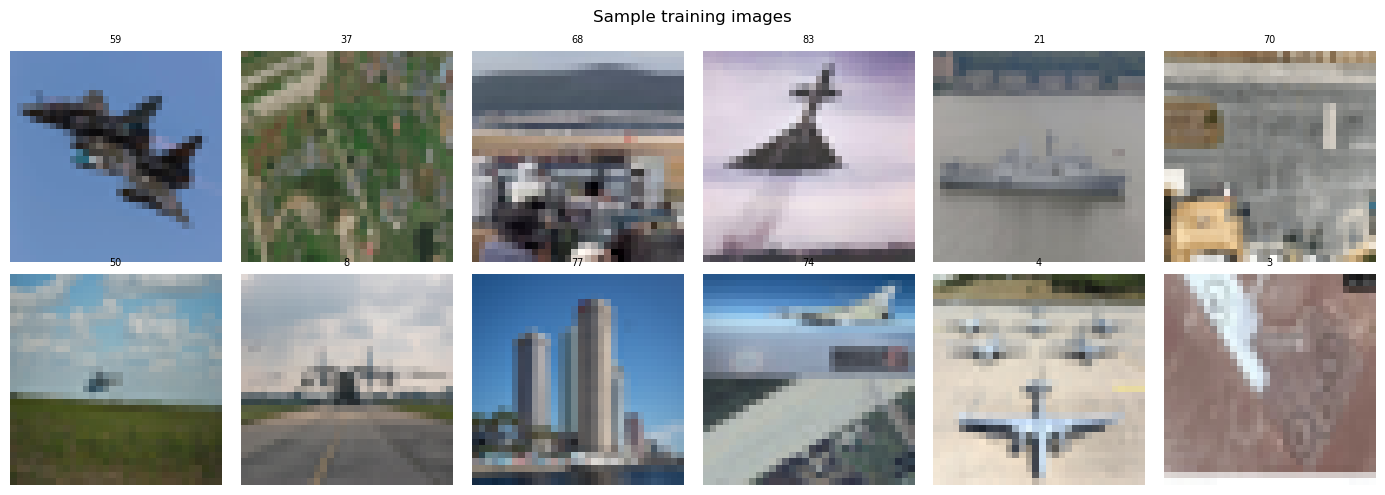

In [34]:
fig, axes = plt.subplots(2, 6, figsize=(14, 5))
idx = np.random.choice(len(X_train_raw), 12, replace=False)
for ax, i in zip(axes.flat, idx):
    ax.imshow(X_train_raw[i])
    ax.set_title(y_train_str[i], fontsize=7)
    ax.axis('off')
plt.suptitle('Sample training images', fontsize=12)
plt.tight_layout(); plt.show()

## 4. Model A — TensorFlow / Keras

Dense network: Flatten → 256 → 128 → softmax(N_CLASSES).  
Softmax outputs a probability per class (replaces sigmoid used in binary case).

In [35]:
tf.random.set_seed(42)

model_tf = keras.Sequential([
    keras.layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
    keras.layers.Flatten(),
    keras.layers.Dense(256, activation='relu',
                       kernel_regularizer=keras.regularizers.l2(1e-4)),  # regularización L2
    keras.layers.BatchNormalization(),    # estabiliza el entrenamiento
    keras.layers.Dropout(0.4),            # subido de 0.3 — más necesario con pocos datos
    keras.layers.Dense(128, activation='relu',
                       kernel_regularizer=keras.regularizers.l2(1e-4)),
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.4),
    keras.layers.Dense(N_CLASSES, activation='softmax'),
], name='TF_Dense')

model_tf.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0003),  # bajado de 0.001 — evita colapso
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model_tf.summary()

Model: "TF_Dense"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       786,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 88)             │        11,352 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 832,472 (3.18 MB)

 Trainable params: 831,704 (3.17 MB)

 Non-trainable params: 768 (3.00 KB)

In [36]:
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_accuracy', patience=8, restore_best_weights=True
)

history = model_tf.fit(
    X_train_raw, y_train,
    validation_data=(X_test_raw, y_test),
    epochs=60, batch_size=16,        # batch más pequeño, más updates por época
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/60
825/825 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.0147 - loss: 5.0663 - val_accuracy: 0.0140 - val_loss: 4.8330
Epoch 2/60
825/825 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.0161 - loss: 4.8162 - val_accuracy: 0.0195 - val_loss: 4.5604
Epoch 3/60
825/825 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.0197 - loss: 4.7200 - val_accuracy: 0.0161 - val_loss: 4.5395
Epoch 4/60
825/825 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.0196 - loss: 4.6503 - val_accuracy: 0.0152 - val_loss: 4.5473
Epoch 5/60
825/825 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.0217 - loss: 4.6126 - val_accuracy: 0.0216 - val_loss: 4.5843
Epoch 6/60
825/825 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.0234 - loss: 4.5794 - val_accuracy: 0.0169 - val_loss: 4.5926
Epoch 7/60
825/825 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.0245 - loss: 4.5485 - val_accuracy: 0.0148 - val_loss: 4.5469
Epoch 8/60
825/825 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.0267 - loss: 4.5325 - val_accuracy: 0

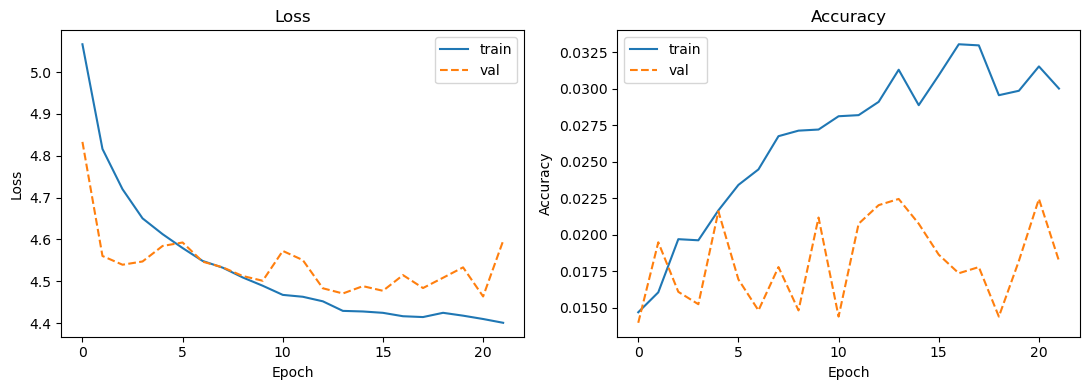

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(history.history['loss'],     label='train')
axes[0].plot(history.history['val_loss'], label='val', ls='--')
axes[0].set(title='Loss', xlabel='Epoch', ylabel='Loss'); axes[0].legend()
axes[1].plot(history.history['accuracy'],     label='train')
axes[1].plot(history.history['val_accuracy'], label='val', ls='--')
axes[1].set(title='Accuracy', xlabel='Epoch', ylabel='Accuracy'); axes[1].legend()
plt.tight_layout(); plt.show()

## 5. Model B — sklearn MLPClassifier

Same architecture (256, 128) for a fair comparison.  
sklearn handles softmax and cross-entropy internally.

In [38]:
mlp = MLPClassifier(
    hidden_layer_sizes=(256, 128),
    activation='relu',
    solver='adam',
    max_iter=30,
    random_state=42,
    verbose=True
)
mlp.fit(X_train_flat, y_train)

sk_train_acc = mlp.score(X_train_flat, y_train)
sk_test_acc  = mlp.score(X_test_flat,  y_test)
print(f'sklearn MLP — train: {sk_train_acc:.4f}  test: {sk_test_acc:.4f}')

Iteration 1, loss = 4.51416480
Iteration 2, loss = 4.48165889
Iteration 3, loss = 4.47990048
Iteration 4, loss = 4.47966119
Iteration 5, loss = 4.47836438
Iteration 6, loss = 4.47512292
Iteration 7, loss = 4.47050064
Iteration 8, loss = 4.46564951
Iteration 9, loss = 4.46293795
Iteration 10, loss = 4.45316920
Iteration 11, loss = 4.44455023
Iteration 12, loss = 4.44351514
Iteration 13, loss = 4.42639722
Iteration 14, loss = 4.42270668
Iteration 15, loss = 4.40052470
Iteration 16, loss = 4.39243802
Iteration 17, loss = 4.37982632
Iteration 18, loss = 4.35985820
Iteration 19, loss = 4.34509160
Iteration 20, loss = 4.33128642
Iteration 21, loss = 4.31908134
Iteration 22, loss = 4.30550266
Iteration 23, loss = 4.28750211
Iteration 24, loss = 4.27199234
Iteration 25, loss = 4.25614394
Iteration 26, loss = 4.24544624
Iteration 27, loss = 4.22882179
Iteration 28, loss = 4.20805695
Iteration 29, loss = 4.19194257
Iteration 30, loss = 4.17138046


/Users/edwinperez/miniconda3/envs/advanced_lab_NN_packs/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (30) reached and the optimization hasn't converged yet.
  warnings.warn(


sklearn MLP — train: 0.0699  test: 0.0254


## 6. Comparison

Model                  Test accuracy
-------------------------------------
TensorFlow Dense              0.0113
sklearn MLP                   0.0254


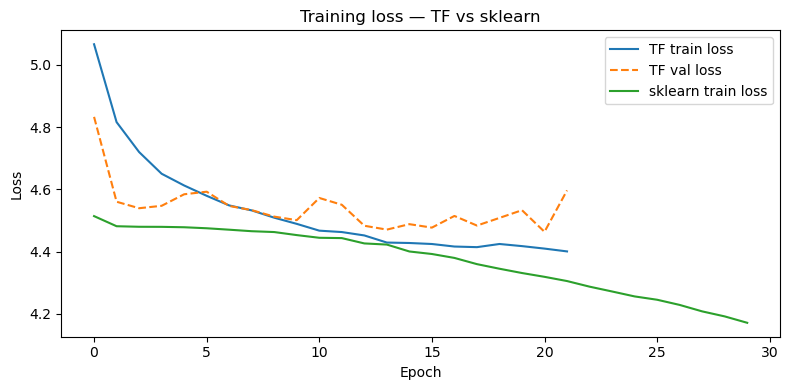

In [39]:
print(f'{"Model":20s}  {"Test accuracy":>14}')
print('-' * 37)
print(f'{"TensorFlow Dense":20s}  {tf_test_acc:>14.4f}')
print(f'{"sklearn MLP":20s}  {sk_test_acc:>14.4f}')

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(history.history['loss'],     label='TF train loss')
ax.plot(history.history['val_loss'], label='TF val loss',  ls='--')
ax.plot(mlp.loss_curve_,             label='sklearn train loss', lw=1.5)
ax.set(xlabel='Epoch', ylabel='Loss', title='Training loss — TF vs sklearn')
ax.legend(); plt.tight_layout(); plt.show()

## 7. Confusion matrix and per-class report (TF model)

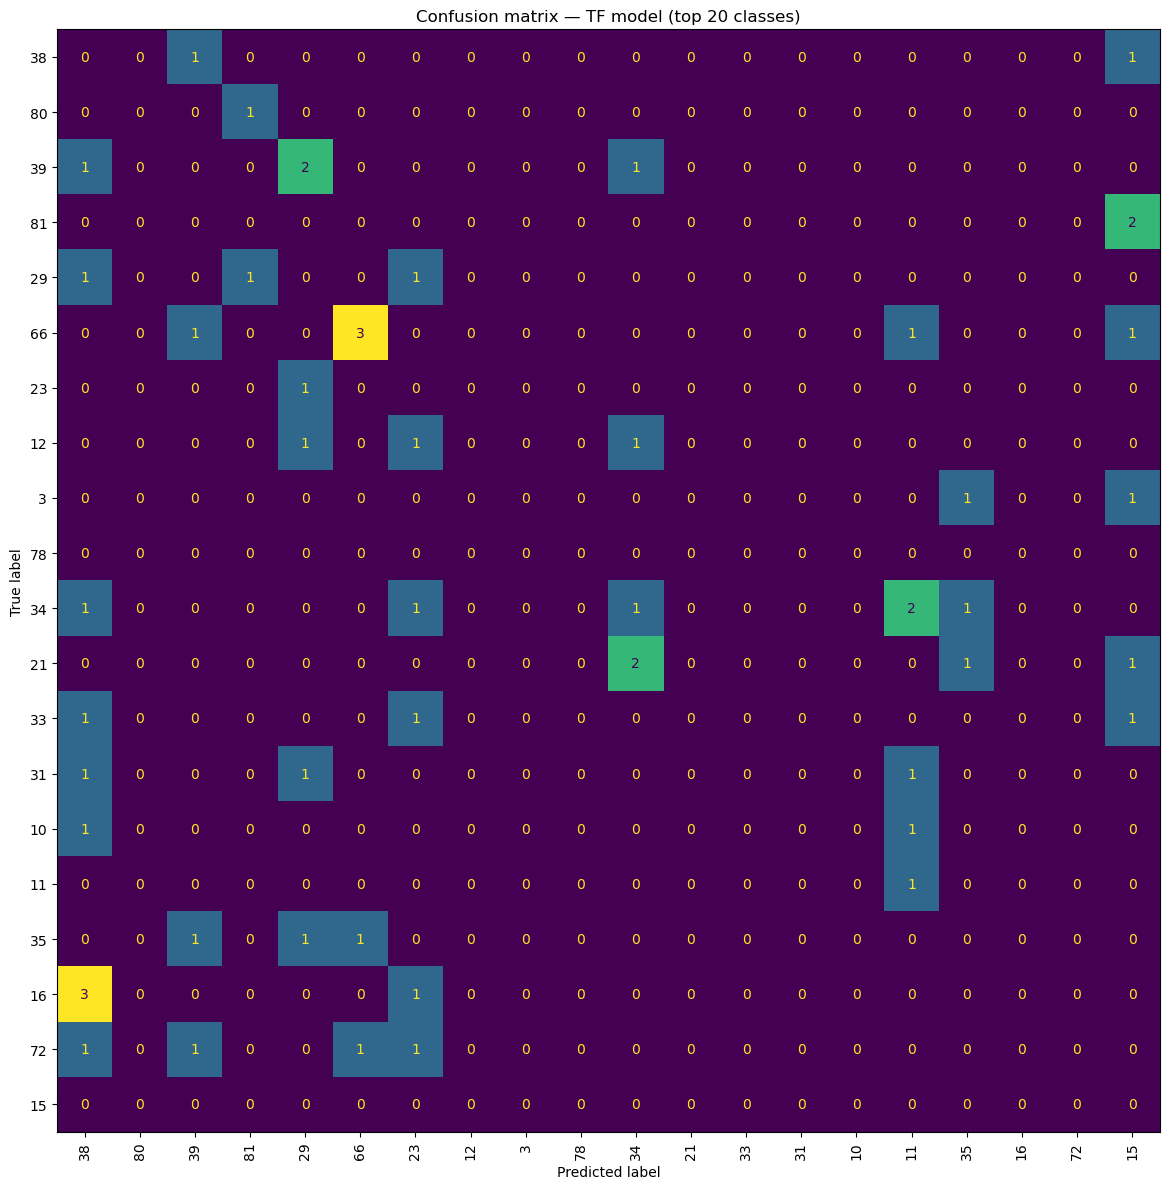

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        30
           1       0.00      0.00      0.00        25
           2       0.00      0.00      0.00        22
           3       0.00      0.00      0.00        32
           4       0.00      0.00      0.00        17
           5       0.00      0.00      0.00        27
           6       0.00      0.00      0.00        26
           7       0.00      0.00      0.00        25
           8       0.00      0.00      0.00        29
           9       0.00      0.00      0.00        27
          10       0.00      0.00      0.00        33
          11       0.03      0.03      0.03        33
          12       0.00      0.00      0.00        32
          13       0.00      0.00      0.00        18
          14       0.00      0.00      0.00        25
          15       0.00      0.00      0.00        35
          16       0.00      0.00      0.00        34
          17       0.00    

In [40]:
y_pred_tf = np.argmax(model_tf.predict(X_test_raw, verbose=0), axis=1)

# Show only top-20 most populated classes to keep the plot readable
top_classes = np.argsort(np.bincount(y_test))[-20:]
mask = np.isin(y_test, top_classes)

fig, ax = plt.subplots(figsize=(14, 12))
ConfusionMatrixDisplay.from_predictions(
    y_test[mask], y_pred_tf[mask],
    labels=top_classes,                      # fuerza la matriz a estas 20 clases exactas
    display_labels=le.classes_[top_classes],
    xticks_rotation=90, ax=ax, colorbar=False
)
ax.set_title('Confusion matrix — TF model (top 20 classes)', fontsize=12)
plt.tight_layout(); plt.show()

print(classification_report(
    y_test, y_pred_tf,
    labels=le.transform(le.classes_),                    # todas las clases presentes
    target_names=[str(c) for c in le.classes_],           # nombres como string
    zero_division=0
))

## 8. Inspect predictions on random test images

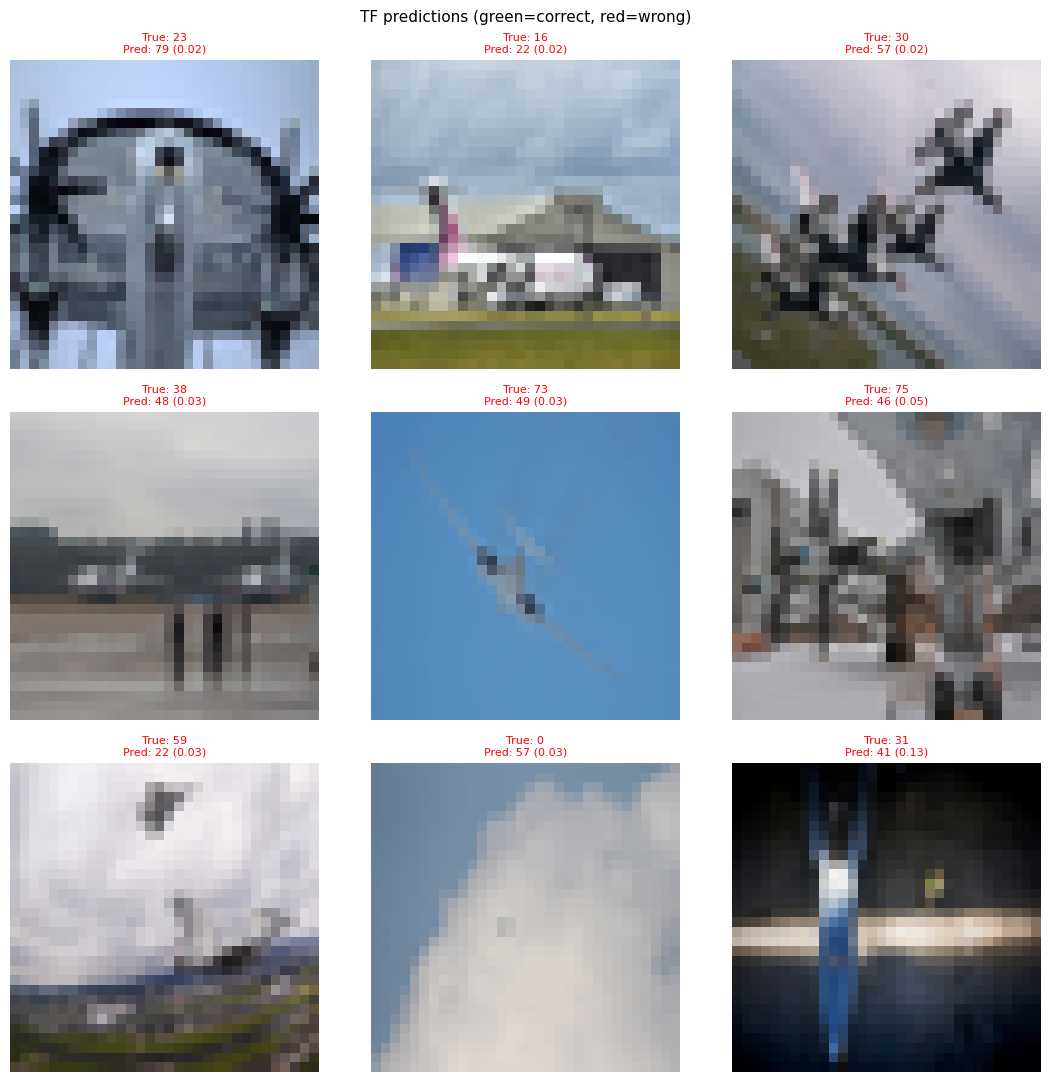

In [41]:
idx = np.random.choice(len(X_test_raw), 9, replace=False)
probs = model_tf.predict(X_test_raw[idx], verbose=0)

fig, axes = plt.subplots(3, 3, figsize=(11, 11))
for ax, i, prob in zip(axes.flat, idx, probs):
    pred  = np.argmax(prob)
    conf  = prob[pred]
    color = 'green' if pred == y_test[i] else 'red'
    ax.imshow(X_test_raw[i])
    ax.set_title(
        f'True: {le.classes_[y_test[i]]}\nPred: {le.classes_[pred]} ({conf:.2f})',
        color=color, fontsize=8
    )
    ax.axis('off')
plt.suptitle('TF predictions (green=correct, red=wrong)', fontsize=11)
plt.tight_layout(); plt.show()